In [ ]:
import numpy as np
#from scipy.special import gammaln # Para calcular log(Gamma(alpha))
#from scipy.stats import gamma
import matplotlib.pyplot as plt


class PoissonRegression:
    def __init__(self, alpha=0.1, lr=0.001, n_iter=10000, tol=1e-6):
        # Inicializo la clase
        self.alpha = alpha
        self.lr = lr
        self.n_iter = n_iter
        self.tol = tol
        self.theta = None
    def grad(self, X, y, theta):
        sub_eta = X.dot(theta)
        loss = np.sum( np.exp(sub_eta) * y - self.alpha * sub_eta)
        # [:, None] convierte el vector en un vector vertical
        # axis = 0 hace que se sumen los elementos de cada columna
        grad = np.sum((( y * np.exp(sub_eta) - self.alpha )[:, None]) * X, axis=0)
        return loss, grad
    def fit(self, X, y):
        X = np.hstack((np.ones((X.shape[0], 1)), X))
        n,m = X.shape
        # Inicializamos theta en ceros
        theta = np.zeros(m)
        prev_loss = np.inf
        # Hago el descenso por gradiente
        for iteration in range(self.n_iter):
            loss, grad = self.grad(X, y, theta)
            theta = theta - self.lr * grad
            # Verificar convergencia
            if np.abs(prev_loss - loss) < self.tol:
                print(f"Convergencia alcanzada en la iteración {iteration}")
                break
            prev_loss = loss
        self.theta = theta
    def predict(self, X):
        X = np.hstack((np.ones((X.shape[0], 1)), X))
        if self.theta is None:
            raise ValueError("El modelo no ha sido ajustado. Llama a fit() primero.")
        eta = np.exp(X.dot(self.theta))
        return self.alpha/eta
    def loss(self, X, y):
        X = np.hstack((np.ones((X.shape[0], 1)), X))
        eta = np.exp(X.dot(self.theta))
        res = - self.alpha * np.log(eta) - eta*y + (self.alpha - 1)*np.log(y) - gammaln(self.alpha)
        return np.sum(res)


In [ ]:
import pandas as pd
# Importo los datos
Data = pd.read_csv(r"Datos/Poisson_Train.csv")
X = Data[["x_1","x_2","x_3","x_4"]].values
y = Data["y"].values
#model = PoissonRegression(alpha=1.1, lr=1e-6, n_iter=10000, tol=1e-8)
#model.fit(X, y)
# Grafico los resultados
#plt.scatter(y,model.predict(X))
# Calculo el R^2
#from sklearn.metrics import r2_score
#print(r2_score(y,model.predict(X)))
# 0.98

In [19]:
# Verificamos si hay NaNs en el DataFrame
print("Cantidad de NaNs en cada columna:")
print(Data.isna().sum())
# Verificamos la proporción de NaNs en cada columna
print("Proporción de NaNs en cada columna:")
print(Data.isna().mean())

Cantidad de NaNs en cada columna:
x_1    0
x_2    0
x_3    0
x_4    0
y      0
dtype: int64
Proporción de NaNs en cada columna:
x_1    0.0
x_2    0.0
x_3    0.0
x_4    0.0
y      0.0
dtype: float64


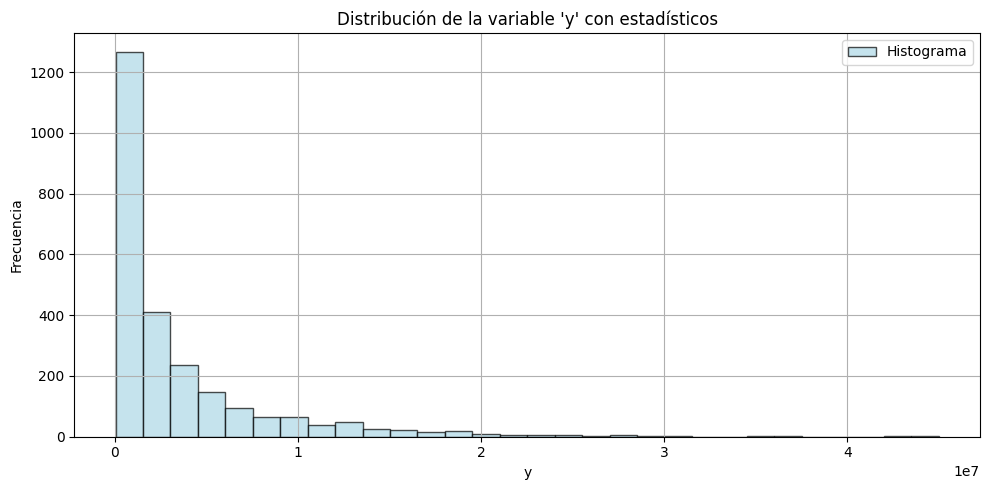

In [20]:
# Estadísticos
media = np.mean(y)
mediana = np.median(y)
std_dev = np.std(y)

# Histograma con líneas
plt.figure(figsize=(10, 5))
plt.hist(y, bins=30, color='lightblue', edgecolor='black', alpha=0.7, label="Histograma")

# Líneas estadísticas
#plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f"Media: {media:,.0f}")
#plt.axvline(mediana, color='green', linestyle='-.', linewidth=2, label=f"Mediana: {mediana:,.0f}")
#plt.axvline(media + std_dev, color='orange', linestyle=':', linewidth=1.5, label=f"Media + 1σ")
#plt.axvline(media - std_dev, color='orange', linestyle=':', linewidth=1.5, label=f"Media - 1σ")

# Estética
plt.title("Distribución de la variable 'y' con estadísticos")
plt.xlabel("y")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Nuestro dataset tiene pinta de seguir una distribución de Poisson con lambda 1